# Umbralización Binaria y Binaria Inversa

Text(0.5, 1.0, 'Imagen Binaria Inversa')

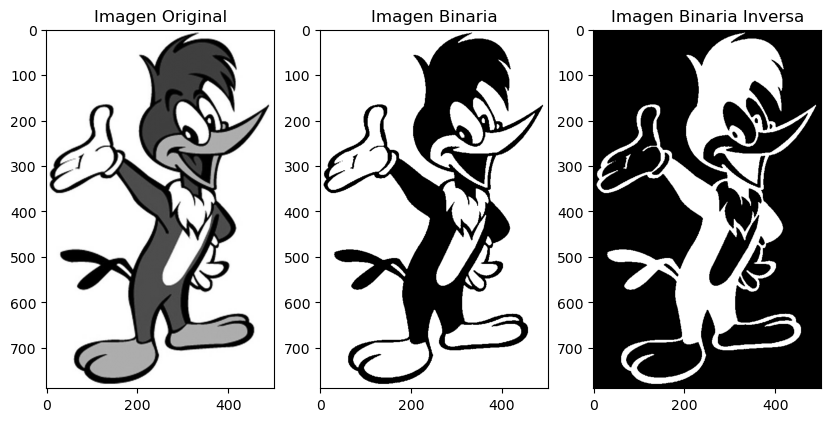

In [ ]:
import cv2
import matplotlib.pyplot as plt
imagen=cv2.imread('loco-1.jpg',0) # lee imagen en escala de grises

# Umbralizacion binaria
_,umbral_binario=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
# Umbralizacion Binaria Inversa
_,umbral_binaria_inv=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original')

plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')
plt.title('Imagen Binaria')

plt.subplot(1,3,3)
plt.imshow(umbral_binaria_inv,cmap='gray')
plt.title('Imagen Binaria Inversa')

# UMBRALIZACIÓN GLOBAL

# Umbralización ISODATA

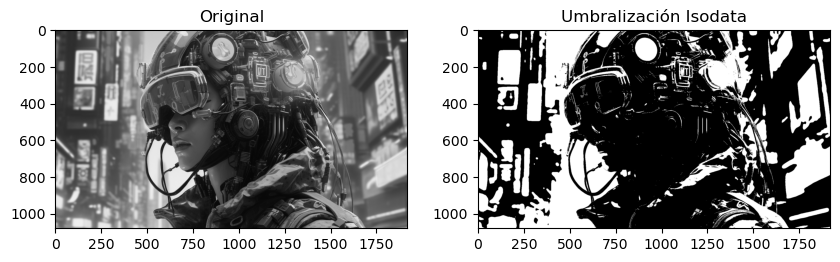

In [6]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def isodata(image):
    # decidimos el umbral inicial de 0 a 255
    umbral=128  # Puedo cambiarlo cuando se requiera
    while True:
        grupo1=image[image<=umbral]# grupo donde el umbral es menor o igual al valor determinado
        grupo2=image[image>umbral] # Mayor al determinado
        # Calculamos la media de cada grupo
        media1=np.mean(grupo1)
        media2=np.mean(grupo2)
        # calculamos el nuevo valor del umbral
        nuevo_umbral=(media1+media2)/2

        # Si el nuevo umbral es igual al inicial se detiene
         
        if abs(nuevo_umbral-umbral)<0.5:
            break
        umbral=nuevo_umbral
        return umbral

imagen=cv2.imread('colores2.jpg',0)    
umbral_isodata=isodata(imagen)
_,umbralizacion_iso=cv2.threshold(imagen,umbral_isodata,255,cv2.THRESH_BINARY)    

# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,2,1)
plt.imshow(imagen,cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(umbralizacion_iso,cmap='gray')
plt.title('Umbralización Isodata')

plt.show()

Umbralizacion de 2 picos 

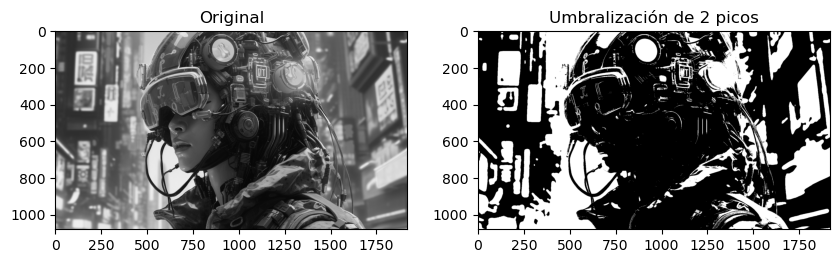

In [5]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

def dos_picos(image):
    # cálculo de histograma
    hist=cv2.calcHist((image),[0],None,[256],[0,256])#hago uso del histograma
    # seleccionamos los picos 
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)# Diferencias entre los picos
    primer_pico=np.argmax(pico_dif[:128])# Pico hasta 127
    segundo_pico=np.argmax(pico_dif[128:])+128 # Pico de 128 para adelante 

    # Calculo del umbral
    umbral=int(primer_pico+segundo_pico)/2
    return umbral

imagen=cv2.imread('colores2.jpg',0)
umbral_2_picos=dos_picos(imagen)
_,nueva=cv2.threshold(imagen,umbral_2_picos,255,cv2.THRESH_BINARY)    

# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,2,1)
plt.imshow(imagen,cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(nueva,cmap='gray')
plt.title('Umbralización de 2 picos')
plt.show()

Método Otsu

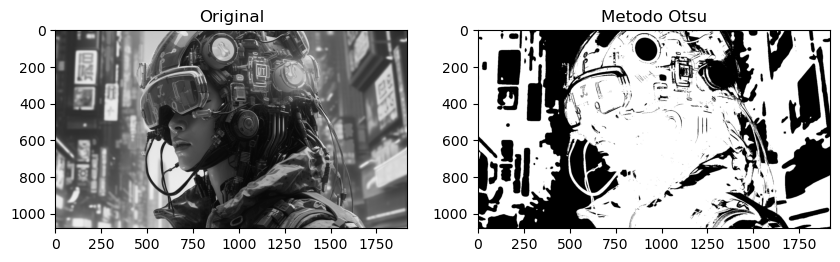

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('colores2.jpg', 0) # escala de grises
_,otsu=cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Podemos combinar diferentes tipos de umbralización, en este caso Otsu con binaria
imagen_fin=np.where(image>otsu,255,0).astype(np.uint8)


# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(imagen_fin,cmap='gray')
plt.title('Metodo Otsu')
plt.show()

UMBRALIZACION VARIABLE PARTICION DE UNA IMAGEN

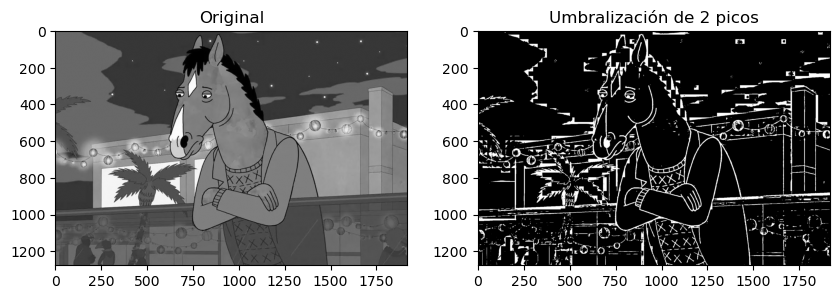

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image)
    for y in range (0,image.shape[0],tam_bloque):# recorremos filas
        for x in range(0,image.shape[1],tam_bloque): # recorremos columnas 
            bloque=image[y:y+tam_bloque,x:x+tam_bloque]# vemos el bloque 
            bloque_media=np.mean(bloque) # intensidad del bloque 
            umbral=bloque_media-c
            umbral_img[y:y+tam_bloque,x:x+tam_bloque]=(bloque>umbral)+255 # umb binaria
    return umbral_img     

tam_b=25
c=10
image=cv2.imread('imagen.jpg',0)
img_fin=variable_part(image,tam_b,c)

# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(img_fin,cmap='gray')
plt.title('Umbralización de 2 picos')
plt.show()

# Propiedades Locales

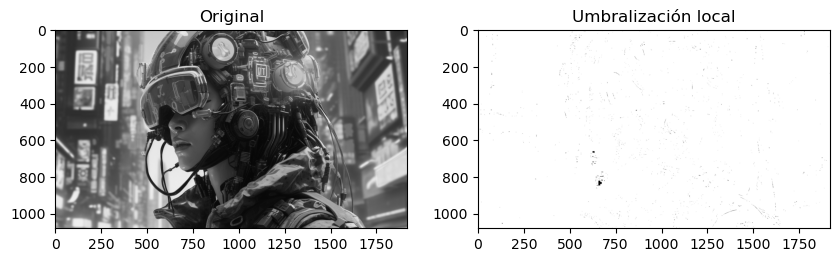

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread('colores2.jpg',0)
def local(image,tam_ventana,k):
    umbr_img=np.zeros_like(image)
    # definir un rastreo de imagen con padding
    pad=tam_ventana//2
    padded_image=cv2.copyMakeBorder(image,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    # recorremos cada pixel
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana=padded_image[y:y+tam_ventana,x:x+tam_ventana]
            # Calculo de media y desviacion
            mean_local=np.mean(ventana)
            std_mean=np.std(ventana)
            # Cálculo de umbral
            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x] > umbral else 0
    return umbr_img

tam_vent=15
k=2
img_fin=local(image,tam_vent,k)     

# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(img_fin,cmap='gray')
plt.title('Umbralización local')
plt.show()


VARIABLE CON OPEN CV

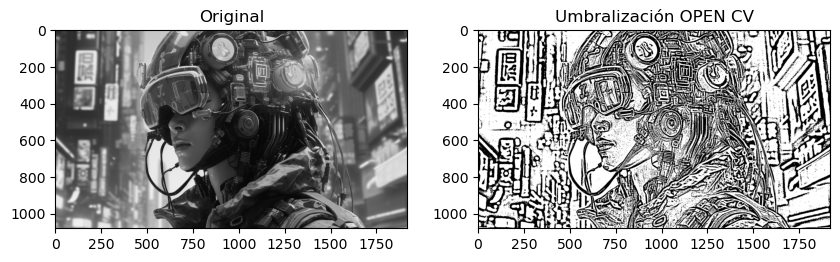

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image=cv2.imread('colores2.jpg',0)

ventana=15
k=2

imagen_fin=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)

# Creamos figura
plt.figure(figsize=(10,5))
 
# Imprimimos 
plt.subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(imagen_fin,cmap='gray')
plt.title('Umbralización OPEN CV')
plt.show()

Otsu Con Fórmulas

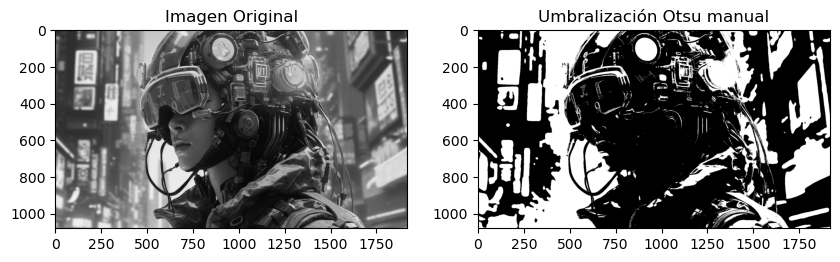

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_manual(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    hist = hist / hist.sum()
    best_t = 0
    max_var = 0
    for t in range(1, 256):
        w1 = hist[:t].sum()
        w2 = 1 - w1
        if w1 > 0 and w2 > 0:
            mean1 = (np.arange(t) * hist[:t]).sum() / w1
            mean2 = (np.arange(t, 256) * hist[t:]).sum() / w2
            var = w1 * w2 * (mean1 - mean2)**2
            if var > max_var:
                max_var = var
                best_t = t
    return best_t

image = cv2.imread('colores2.jpg', 0)
otsu_t = otsu_manual(image)
_, imagen_fin = cv2.threshold(image, otsu_t, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Umbralización Otsu manual')

plt.show()